## Section 1: Import Libraries and Setup

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.interpolate import CubicSpline
from datetime import timedelta, datetime
import pickle
import gc
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Use Polars for efficient large file loading
try:
    import polars as pl

    POLARS_AVAILABLE = True
except ImportError:
    POLARS_AVAILABLE = False
    print("⚠️  Polars not available, will use pandas")

# GPU acceleration support
NUMBA_GPU_AVAILABLE = False
try:
    from numba import cuda, jit

    NUMBA_GPU_AVAILABLE = cuda.is_available()
except:
    pass

# Setup paths
processed_data_dir = Path(
    r"F:\PyTorch_GPU\maritime_monitoring_preprocessing\processed_data"
)
output_dir = Path(
    r"F:\PyTorch_GPU\maritime_monitoring_preprocessing\interpolated_results"
)
output_dir.mkdir(exist_ok=True, parents=True)

print(f"Input Directory: {processed_data_dir}")
print(f"Output Directory: {output_dir}")
print(f"GPU Acceleration Available: {NUMBA_GPU_AVAILABLE}")
print(f"Input directory exists: {processed_data_dir.exists()}")

Input Directory: F:\PyTorch_GPU\maritime_monitoring_preprocessing\processed_data
Output Directory: F:\PyTorch_GPU\maritime_monitoring_preprocessing\interpolated_results
GPU Acceleration Available: True
Input directory exists: True


In [2]:
# Quick diagnostic: Check what's in the processed_data directory
import os

print("=" * 80)
print("DIRECTORY DIAGNOSTIC CHECK")
print("=" * 80)

print(f"\nChecking: {processed_data_dir}")
print(f"Exists: {processed_data_dir.exists()}")
print(f"Is directory: {processed_data_dir.is_dir()}")

if processed_data_dir.exists():
    # List all files
    all_items = list(processed_data_dir.iterdir())
    print(f"\nTotal items in directory: {len(all_items)}")

    csv_count = len(list(processed_data_dir.glob("*.csv")))
    parquet_count = len(list(processed_data_dir.glob("*.parquet")))
    pkl_count = len(list(processed_data_dir.glob("*.pkl")))

    print(f"  CSV files: {csv_count}")
    print(f"  Parquet files: {parquet_count}")
    print(f"  PKL files: {pkl_count}")
    print(f"  Other: {len(all_items) - csv_count - parquet_count - pkl_count}")

    print(f"\nFirst 15 items:")
    for i, item in enumerate(sorted(all_items)[:15]):
        size = item.stat().st_size / (1024**2) if item.is_file() else 0
        item_type = "DIR" if item.is_dir() else "FILE"
        print(f"  {i+1:2d}. {item.name:<50} ({item_type}, {size:.2f} MB)")
else:
    print("\n❌ ERROR: Directory does not exist!")
    print(f"Expected path: {processed_data_dir.absolute()}")

DIRECTORY DIAGNOSTIC CHECK

Checking: F:\PyTorch_GPU\maritime_monitoring_preprocessing\processed_data
Exists: True
Is directory: True

Total items in directory: 9
  CSV files: 8
  Parquet files: 0
  PKL files: 0
  Other: 1

First 15 items:
   1. ais_2020_01_04.db                                  (FILE, 653.33 MB)
   2. AIS_2020_01_05.csv                                 (FILE, 671.69 MB)
   3. AIS_2020_01_06.csv                                 (FILE, 693.35 MB)
   4. AIS_2020_01_07.csv                                 (FILE, 670.71 MB)
   5. AIS_2020_01_08.csv                                 (FILE, 676.88 MB)
   6. AIS_2020_01_09.csv                                 (FILE, 662.82 MB)
   7. AIS_2020_01_10.csv                                 (FILE, 658.50 MB)
   8. AIS_2020_01_11.csv                                 (FILE, 650.11 MB)
   9. AIS_2020_01_12.csv                                 (FILE, 667.68 MB)


In [3]:
# Diagnose CSV file encoding and structure
print("=" * 80)
print("CSV FILE ENCODING DIAGNOSTIC")
print("=" * 80)

# Check first file
test_file = processed_data_dir / "AIS_2020_01_05.csv"

print(f"\nTesting file: {test_file.name}")
print(f"File size: {test_file.stat().st_size / (1024**2):.2f} MB")

# Read raw bytes to inspect
with open(test_file, "rb") as f:
    first_line = f.readline()

print(f"\nFirst bytes (raw): {first_line[:200]}")
print(f"\nTrying to decode with different methods:")

# Try various encodings
encodings_to_try = ["utf-8-sig", "utf-8", "latin-1", "iso-8859-1", "cp1252", "ascii"]

for enc in encodings_to_try:
    try:
        decoded = first_line.decode(enc)
        print(f"  ✅ {enc:15} | {decoded[:80]}")
        break
    except Exception as e:
        print(f"  ❌ {enc:15} | Failed")

print(f"\n" + "=" * 80)
print("TESTING PANDAS READ STRATEGIES")
print("=" * 80)

# Strategy 1: utf-8 with errors='replace'
print("\nStrategy 1: pd.read_csv(utf-8, errors='replace', on_bad_lines='skip')")
try:
    df_test = pd.read_csv(
        test_file, nrows=5, encoding="utf-8", on_bad_lines="skip", engine="c"
    )
    print(f"  ✅ SUCCESS")
    print(f"  Columns: {df_test.columns.tolist()}")
    print(f"  First row: {df_test.iloc[0].to_dict() if len(df_test) > 0 else 'Empty'}")
    best_strategy = "utf-8 + on_bad_lines='skip' + engine='c'"
except Exception as e:
    print(f"  ❌ Failed: {str(e)[:80]}")
    best_strategy = None

# Strategy 2: latin-1 (never fails but might have wrong chars)
if best_strategy is None:
    print("\nStrategy 2: pd.read_csv(latin-1, on_bad_lines='skip')")
    try:
        df_test = pd.read_csv(
            test_file, nrows=5, encoding="latin-1", on_bad_lines="skip", engine="c"
        )
        print(f"  ✅ SUCCESS")
        print(f"  Columns: {df_test.columns.tolist()}")
        best_strategy = "latin-1 + on_bad_lines='skip'"
    except Exception as e:
        print(f"  ❌ Failed: {str(e)[:80]}")

# Strategy 3: with dtype coercion
if best_strategy is None:
    print("\nStrategy 3: pd.read_csv(utf-8, dtype=str, on_bad_lines='skip')")
    try:
        df_test = pd.read_csv(
            test_file,
            nrows=5,
            encoding="utf-8",
            dtype=str,
            on_bad_lines="skip",
            engine="c",
        )
        print(f"  ✅ SUCCESS")
        print(f"  Columns: {df_test.columns.tolist()}")
        best_strategy = "utf-8 + dtype=str + on_bad_lines='skip'"
    except Exception as e:
        print(f"  ❌ Failed: {str(e)[:80]}")

print(f"\n{'='*80}")
if best_strategy:
    print(f"✅ RECOMMENDED STRATEGY: {best_strategy}")
else:
    print(f"⚠️  All strategies failed. Will try alternative approaches in next cell.")
print(f"{'='*80}")

CSV FILE ENCODING DIAGNOSTIC

Testing file: AIS_2020_01_05.csv
File size: 671.69 MB

First bytes (raw): b'MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo,TransceiverClass\r\n'

Trying to decode with different methods:
  ✅ utf-8-sig       | MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Sta

TESTING PANDAS READ STRATEGIES

Strategy 1: pd.read_csv(utf-8, errors='replace', on_bad_lines='skip')
  ✅ SUCCESS
  Columns: ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo', 'TransceiverClass']
  First row: {'MMSI': 367005220, 'BaseDateTime': '2020-01-05T00:00:00', 'LAT': 30.06265, 'LON': -93.35127, 'SOG': 5.1, 'COG': 227.0, 'Heading': 511.0, 'VesselName': nan, 'IMO': nan, 'CallSign': nan, 'VesselType': nan, 'Status': 0, 'Length': nan, 'Width': nan, 'Draft': nan, 'Cargo': nan, 'TransceiverClass': 'A'}



## Section 2: Load and Consolidate Data from Processed Data Folder

In [3]:
def detect_column_names(df):
    """
    Auto-detect column names for time, latitude, longitude, and MMSI.
    """
    columns = df.columns.tolist()

    time_col = None
    for col in ["BaseDateTime", "timestamp", "DateTime", "Time", "Timestamp"]:
        if col in columns:
            time_col = col
            break

    lat_col = None
    for col in ["LAT", "Latitude", "lat", "Lat"]:
        if col in columns:
            lat_col = col
            break

    lon_col = None
    for col in ["LON", "Longitude", "lon", "Long"]:
        if col in columns:
            lon_col = col
            break

    mmsi_col = None
    for col in ["MMSI", "mmsi", "Mmsi"]:
        if col in columns:
            mmsi_col = col
            break

    imo_col = None
    for col in ["IMO", "imo", "Imo"]:
        if col in columns:
            imo_col = col
            break

    return {
        "time_col": time_col,
        "lat_col": lat_col,
        "lon_col": lon_col,
        "mmsi_col": mmsi_col,
        "imo_col": imo_col,
    }


def load_all_data_chunked(data_dir, chunksize=50000, temp_dir=None):
    """
    Load all CSV files in chunks, save to temporary parquet files, then consolidate.
    This avoids memory explosion when concatenating large number of chunks.
    Memory-optimized approach: converts CSV chunks to parquet before final consolidation.
    """
    print("\n" + "=" * 80)
    print(
        "LOADING AND CONSOLIDATING DATA FROM PROCESSED_DATA FOLDER (MEMORY-OPTIMIZED)"
    )
    print("=" * 80)

    # Check directory
    print(f"\n[DEBUG] Checking directory: {data_dir}")
    print(f"[DEBUG] Directory exists: {data_dir.exists()}")

    if not data_dir.exists():
        print(f"❌ ERROR: Directory does not exist: {data_dir}")
        return None, None

    # Create temp directory for intermediate parquet files
    if temp_dir is None:
        temp_dir = Path(data_dir.parent) / ".temp_parquet_chunks"
    temp_dir = Path(temp_dir)
    temp_dir.mkdir(exist_ok=True, parents=True)

    print(f"Temp directory: {temp_dir}")

    # Find all data files
    csv_files = sorted(data_dir.glob("*.csv"))
    parquet_files = sorted(data_dir.glob("*.parquet"))
    all_files = csv_files + parquet_files

    print(f"\nFound {len(csv_files)} CSV files")
    print(f"Found {len(parquet_files)} Parquet files")
    print(f"Total files to load: {len(all_files)}")
    print(
        f"Loading strategy: Chunked mode with disk-based consolidation (chunk size: {chunksize:,} rows)"
    )

    if len(all_files) == 0:
        print("❌ No data files found!")
        return None, None

    # Load and save files to temp parquet
    detected_cols = None
    successful_files = 0
    failed_files = 0
    temp_parquet_files = []

    for file_path in tqdm(all_files, desc="Loading and converting files"):
        try:
            file_chunks = 0
            accumulated_chunks = []

            # Load file in chunks
            if file_path.suffix == ".csv":
                try:
                    # Read CSV in chunks
                    for chunk in pd.read_csv(
                        file_path,
                        chunksize=chunksize,
                        on_bad_lines="skip",
                        encoding="utf-8",
                        engine="c",
                    ):
                        # Auto-detect columns from first chunk of first file
                        if detected_cols is None:
                            detected_cols = detect_column_names(chunk)
                            print(
                                f"📋 Column detection from {file_path.name}: {detected_cols}"
                            )

                        accumulated_chunks.append(chunk)
                        file_chunks += 1

                        # Every 5 chunks, consolidate and clear to prevent memory bloat
                        if file_chunks % 5 == 0:
                            partial_df = pd.concat(
                                accumulated_chunks, ignore_index=True
                            )
                            accumulated_chunks = []
                            del partial_df
                            gc.collect()

                    successful_files += 1

                except Exception as e:
                    print(f"⚠️  {file_path.name}: Failed - {str(e)[:50]}")
                    failed_files += 1
                    continue

            elif file_path.suffix == ".parquet":
                try:
                    chunk = pd.read_parquet(file_path)
                    if detected_cols is None:
                        detected_cols = detect_column_names(chunk)
                        print(
                            f"📋 Column detection from {file_path.name}: {detected_cols}"
                        )
                    accumulated_chunks.append(chunk)
                    file_chunks = 1
                    successful_files += 1
                except Exception as e:
                    print(f"⚠️  {file_path.name}: Failed - {str(e)[:50]}")
                    failed_files += 1
                    continue

            # Save accumulated chunks for this file to temp parquet
            if accumulated_chunks:
                temp_parquet = (
                    temp_dir / f"temp_{file_path.stem}_{successful_files}.parquet"
                )
                partial_df = pd.concat(accumulated_chunks, ignore_index=True)
                partial_df.to_parquet(temp_parquet, compression="snappy", index=False)
                temp_parquet_files.append(temp_parquet)
                del accumulated_chunks, partial_df
                gc.collect()

            print(f"✅ {file_path.name}: Converted to temp parquet file")

        except Exception as e:
            print(f"❌ Error processing {file_path.name}: {str(e)[:80]}")
            failed_files += 1
            continue

    print(f"\n{'='*80}")
    print(f"Load Summary: {successful_files} succeeded, {failed_files} failed")
    print(f"Temp parquet files created: {len(temp_parquet_files)}")
    print(f"{'='*80}")

    if not temp_parquet_files:
        print("❌ FATAL: Failed to create ANY temp parquet files!")
        return None, None

    # Now consolidate temp parquet files (much more memory-efficient than raw chunks)
    print(
        f"\nConsolidating {len(temp_parquet_files)} parquet files into final DataFrame..."
    )

    all_parquet_chunks = []
    for pq_file in tqdm(temp_parquet_files, desc="Reading temp parquet files"):
        df_chunk = pd.read_parquet(pq_file)
        all_parquet_chunks.append(df_chunk)

    consolidated_df = pd.concat(all_parquet_chunks, ignore_index=True)

    # Clean up memory and temp files
    del all_parquet_chunks
    gc.collect()

    # Clean up temp directory
    print(f"\nCleaning up temporary files...")
    for pq_file in temp_parquet_files:
        pq_file.unlink(missing_ok=True)
    temp_dir.rmdir()

    print(f"\nConsolidated DataFrame shape: {consolidated_df.shape}")
    print(
        f"Memory usage: {consolidated_df.memory_usage(deep=True).sum() / (1024**2):.2f} MB"
    )

    return consolidated_df, detected_cols


# Load data using chunked approach
print("Starting data loading with chunked approach to manage memory...")
consolidated_df, detected_cols = load_all_data_chunked(
    processed_data_dir, chunksize=50000
)

if consolidated_df is None:
    raise Exception("Failed to load data!")

print(f"\nDetected Columns:")
for key, val in detected_cols.items():
    print(f"  {key}: {val}")

Starting data loading with chunked approach to manage memory...

LOADING AND CONSOLIDATING DATA FROM PROCESSED_DATA FOLDER (MEMORY-OPTIMIZED)

[DEBUG] Checking directory: F:\PyTorch_GPU\maritime_monitoring_preprocessing\processed_data
[DEBUG] Directory exists: True
Temp directory: F:\PyTorch_GPU\maritime_monitoring_preprocessing\.temp_parquet_chunks

Found 8 CSV files
Found 0 Parquet files
Total files to load: 8
Loading strategy: Chunked mode with disk-based consolidation (chunk size: 50,000 rows)


Loading and converting files:   0%|          | 0/8 [00:00<?, ?it/s]

📋 Column detection from AIS_2020_01_05.csv: {'time_col': 'BaseDateTime', 'lat_col': 'LAT', 'lon_col': 'LON', 'mmsi_col': 'MMSI', 'imo_col': 'IMO'}
✅ AIS_2020_01_05.csv: Converted to temp parquet file
✅ AIS_2020_01_06.csv: Converted to temp parquet file
✅ AIS_2020_01_07.csv: Converted to temp parquet file
✅ AIS_2020_01_08.csv: Converted to temp parquet file
✅ AIS_2020_01_09.csv: Converted to temp parquet file
✅ AIS_2020_01_10.csv: Converted to temp parquet file
✅ AIS_2020_01_11.csv: Converted to temp parquet file
✅ AIS_2020_01_12.csv: Converted to temp parquet file

Load Summary: 8 succeeded, 0 failed
Temp parquet files created: 7

Consolidating 7 parquet files into final DataFrame...


Reading temp parquet files:   0%|          | 0/7 [00:00<?, ?it/s]


Cleaning up temporary files...

Consolidated DataFrame shape: (565906, 17)
Memory usage: 212.39 MB

Detected Columns:
  time_col: BaseDateTime
  lat_col: LAT
  lon_col: LON
  mmsi_col: MMSI
  imo_col: IMO


## Section 3: Create Consolidated Parquet File by Date Range

In [4]:
# Validate and clean data
time_col = detected_cols["time_col"]
lat_col = detected_cols["lat_col"]
lon_col = detected_cols["lon_col"]
mmsi_col = detected_cols["mmsi_col"]

if not all([time_col, lat_col, lon_col, mmsi_col]):
    raise Exception(
        f"Missing required columns: time={time_col}, lat={lat_col}, lon={lon_col}, mmsi={mmsi_col}"
    )

print("\n" + "=" * 80)
print("CREATING CONSOLIDATED PARQUET FILE")
print("=" * 80)

# Convert timestamp to datetime
if consolidated_df[time_col].dtype == "object":
    consolidated_df[time_col] = pd.to_datetime(
        consolidated_df[time_col], errors="coerce"
    )

# Remove rows with missing critical values
initial_rows = len(consolidated_df)
consolidated_df = consolidated_df.dropna(subset=[time_col, lat_col, lon_col, mmsi_col])
print(
    f"\nRows after removing missing values: {len(consolidated_df)} (removed {initial_rows - len(consolidated_df)})"
)

# Sort by timestamp and MMSI
consolidated_df = consolidated_df.sort_values([time_col, mmsi_col]).reset_index(
    drop=True
)

# Get date range
min_date = consolidated_df[time_col].min()
max_date = consolidated_df[time_col].max()
date_range_str = f"{min_date.strftime('%Y%m%d')}_{max_date.strftime('%Y%m%d')}"

print(f"\nDate Range: {min_date.date()} to {max_date.date()}")
print(f"Total Data Points: {len(consolidated_df):,}")
print(f"Unique Vessels (MMSI): {consolidated_df[mmsi_col].nunique():,}")
print(
    f"Memory usage: {consolidated_df.memory_usage(deep=True).sum() / (1024**2):.2f} MB"
)

# Save consolidated parquet file
consolidated_file = output_dir / f"consolidated_ais_data_{date_range_str}.parquet"
consolidated_df.to_parquet(consolidated_file, compression="snappy", index=False)
file_size_mb = consolidated_file.stat().st_size / (1024**2)

print(f"\n✅ Consolidated parquet file saved:")
print(f"   File: {consolidated_file.name}")
print(f"   Size: {file_size_mb:.2f} MB")


CREATING CONSOLIDATED PARQUET FILE

Rows after removing missing values: 565906 (removed 0)

Date Range: 2020-01-05 to 2020-01-12
Total Data Points: 565,906
Unique Vessels (MMSI): 15,173
Memory usage: 175.69 MB

✅ Consolidated parquet file saved:
   File: consolidated_ais_data_20200105_20200112.parquet
   Size: 15.71 MB


## Section 4: Group and Sort Vessels by MMSI

In [5]:
print("\n" + "=" * 80)
print("GROUPING AND SORTING VESSELS BY MMSI")
print("=" * 80)

# Get unique MMSIs sorted
unique_mmsis = sorted(consolidated_df[mmsi_col].unique())
total_vessels = len(unique_mmsis)

print(f"\nTotal unique vessels (MMSI): {total_vessels:,}")
print(f"\nMMSI Range: {min(unique_mmsis)} to {max(unique_mmsis)}")

# Show sample of MMSI distribution
mmsi_counts = consolidated_df[mmsi_col].value_counts().sort_index()
print(f"\nData points per vessel (statistics):")
print(f"  Min: {mmsi_counts.min()}")
print(f"  Max: {mmsi_counts.max()}")
print(f"  Mean: {mmsi_counts.mean():.1f}")
print(f"  Median: {mmsi_counts.median():.1f}")

print(f"\nTop 10 vessels by data point count:")
for mmsi, count in mmsi_counts.head(10).items():
    print(f"  MMSI {mmsi}: {count:,} points")


GROUPING AND SORTING VESSELS BY MMSI

Total unique vessels (MMSI): 15,173

MMSI Range: 0 to 1072130231

Data points per vessel (statistics):
  Min: 1
  Max: 6704
  Mean: 37.3
  Median: 31.0

Top 10 vessels by data point count:
  MMSI 0: 21 points
  MMSI 11: 5 points
  MMSI 12: 12 points
  MMSI 18: 32 points
  MMSI 111: 3 points
  MMSI 4910: 1 points
  MMSI 270995: 74 points
  MMSI 507027: 46 points
  MMSI 737255: 13 points
  MMSI 1056261: 69 points


## Section 5: Apply Cubic Spline Interpolation at 15-Minute Intervals

In [6]:
def interpolate_vessel_trajectory_15min(df_vessel, time_col, lat_col, lon_col):
    """
    Interpolate a single vessel's trajectory at 15-minute intervals using cubic spline.
    """
    if len(df_vessel) < 2:
        return pd.DataFrame()

    # Select required columns and drop NaN
    df = df_vessel[[time_col, lat_col, lon_col]].dropna().copy()
    df = df.sort_values(time_col).reset_index(drop=True)

    if len(df) < 2:
        return pd.DataFrame()

    # Convert timestamps to numeric (seconds since start)
    t_start = df[time_col].min()
    t_numeric = (df[time_col] - t_start).dt.total_seconds().values

    lat_vals = df[lat_col].values
    lon_vals = df[lon_col].values

    # Build cubic splines for lat/lon
    try:
        cs_lat = CubicSpline(t_numeric, lat_vals, bc_type="not-a-knot")
        cs_lon = CubicSpline(t_numeric, lon_vals, bc_type="not-a-knot")
    except Exception:
        return pd.DataFrame()

    # Create new time grid at 15-minute intervals
    t_min, t_max = t_numeric.min(), t_numeric.max()
    dt_seconds = 15 * 60  # 15 minutes
    t_interp = np.arange(t_min, t_max + dt_seconds, dt_seconds)

    # Evaluate splines at new time points
    lat_interp = cs_lat(t_interp)
    lon_interp = cs_lon(t_interp)

    # Convert back to timestamps
    timestamps_interp = [t_start + timedelta(seconds=float(t)) for t in t_interp]

    # Mark which points are original vs interpolated
    is_interpolated = ~np.isin(t_interp, t_numeric)

    result = pd.DataFrame(
        {
            time_col: timestamps_interp,
            lat_col: lat_interp,
            lon_col: lon_interp,
            "interpolated": is_interpolated,
        }
    )

    return result


print("\n" + "=" * 80)
print("APPLYING CUBIC SPLINE INTERPOLATION AT 15-MINUTE INTERVALS")
print("=" * 80)

print(f"\nInterpolating {total_vessels:,} vessels...")
print(f"Time interval: 15 minutes")
print(f"Interpolation method: Cubic Spline (bc_type='not-a-knot')")

# Process each vessel and collect interpolated data
interpolated_vessels = []
total_points_before = len(consolidated_df)
total_points_after = 0
successful_vessels = 0
error_count = 0

for mmsi in tqdm(unique_mmsis, desc="Interpolating vessels"):
    try:
        # Get vessel trajectory
        vessel_df = consolidated_df[consolidated_df[mmsi_col] == mmsi].copy()

        # Interpolate
        interp_df = interpolate_vessel_trajectory_15min(
            vessel_df, time_col, lat_col, lon_col
        )

        if not interp_df.empty:
            # Add MMSI back
            interp_df[mmsi_col] = mmsi
            interpolated_vessels.append(interp_df)
            total_points_after += len(interp_df)
            successful_vessels += 1

        del vessel_df, interp_df

    except Exception as e:
        error_count += 1
        continue

print(f"\n✅ Interpolation complete!")
print(f"\nResults:")
print(
    f"  Vessels successfully interpolated: {successful_vessels:,} / {total_vessels:,}"
)
print(f"  Vessels with errors: {error_count:,}")
print(f"  Total data points before interpolation: {total_points_before:,}")
print(f"  Total data points after interpolation: {total_points_after:,}")
if total_points_before > 0:
    expansion_factor = total_points_after / total_points_before
    print(f"  Data expansion factor: {expansion_factor:.3f}x")


APPLYING CUBIC SPLINE INTERPOLATION AT 15-MINUTE INTERVALS

Interpolating 15,173 vessels...
Time interval: 15 minutes
Interpolation method: Cubic Spline (bc_type='not-a-knot')


Interpolating vessels:   0%|          | 0/15173 [00:00<?, ?it/s]


✅ Interpolation complete!

Results:
  Vessels successfully interpolated: 14,496 / 15,173
  Vessels with errors: 0
  Total data points before interpolation: 565,906
  Total data points after interpolation: 6,863,558
  Data expansion factor: 12.128x


## Section 6: Save Interpolated Data to New Parquet File

In [7]:
print("\n" + "=" * 80)
print("SAVING INTERPOLATED DATA TO PARQUET FILE")
print("=" * 80)

if not interpolated_vessels:
    raise Exception("No interpolated data to save!")

# Combine all interpolated vessels
print(f"\nCombining {len(interpolated_vessels)} vessel DataFrames...")
interpolated_df = pd.concat(interpolated_vessels, ignore_index=True)

# Clean up memory
del interpolated_vessels
gc.collect()

# Sort by MMSI and timestamp
interpolated_df = interpolated_df.sort_values([mmsi_col, time_col]).reset_index(
    drop=True
)

print(f"\nInterpolated DataFrame shape: {interpolated_df.shape}")
print(
    f"Memory usage: {interpolated_df.memory_usage(deep=True).sum() / (1024**2):.2f} MB"
)

# Save to parquet
interpolated_file = output_dir / f"interpolated_ais_data_{date_range_str}_15min.parquet"
interpolated_df.to_parquet(interpolated_file, compression="snappy", index=False)
interp_file_size_mb = interpolated_file.stat().st_size / (1024**2)

print(f"\n✅ Interpolated parquet file saved:")
print(f"   File: {interpolated_file.name}")
print(f"   Size: {interp_file_size_mb:.2f} MB")
print(f"   Location: {output_dir.absolute()}")


SAVING INTERPOLATED DATA TO PARQUET FILE

Combining 14496 vessel DataFrames...

Interpolated DataFrame shape: (6863558, 5)
Memory usage: 216.00 MB

✅ Interpolated parquet file saved:
   File: interpolated_ais_data_20200105_20200112_15min.parquet
   Size: 159.04 MB
   Location: F:\PyTorch_GPU\maritime_monitoring_preprocessing\interpolated_results


## Section 7: Generate Processing Statistics and Visualizations

In [8]:
print("\n" + "=" * 80)
print("PROCESSING STATISTICS SUMMARY")
print("=" * 80)

# Calculate statistics
date_range = (max_date - min_date).days + 1
expansion_factor = (
    total_points_after / total_points_before if total_points_before > 0 else 0
)
avg_points_per_vessel_before = total_points_before / total_vessels
avg_points_per_vessel_after = (
    total_points_after / successful_vessels if successful_vessels > 0 else 0
)

print(f"\n📊 DATA CONSOLIDATION:")
print(f"  Total files loaded: 8")
print(f"  Date range: {date_range} days")
print(f"  Date span: {min_date.date()} to {max_date.date()}")

print(f"\n🚢 VESSEL INFORMATION:")
print(f"  Total unique vessels: {total_vessels:,}")
print(f"  Successfully interpolated: {successful_vessels:,}")
print(f"  Interpolation success rate: {100*successful_vessels/total_vessels:.1f}%")

print(f"\n📈 DATA POINTS:")
print(f"  Before interpolation: {total_points_before:,}")
print(f"  After interpolation: {total_points_after:,}")
print(f"  Data expansion factor: {expansion_factor:.3f}x")
print(f"  Average points per vessel (before): {avg_points_per_vessel_before:.1f}")
print(f"  Average points per vessel (after): {avg_points_per_vessel_after:.1f}")

print(f"\n💾 FILE STORAGE:")
print(f"  Consolidated file: {consolidated_file.name}")
print(f"    Size: {file_size_mb:.2f} MB")
print(f"  Interpolated file: {interpolated_file.name}")
print(f"    Size: {interp_file_size_mb:.2f} MB")
print(f"  Total output size: {file_size_mb + interp_file_size_mb:.2f} MB")
print(f"  Output directory: {output_dir.absolute()}")


PROCESSING STATISTICS SUMMARY

📊 DATA CONSOLIDATION:
  Total files loaded: 8
  Date range: 8 days
  Date span: 2020-01-05 to 2020-01-12

🚢 VESSEL INFORMATION:
  Total unique vessels: 15,173
  Successfully interpolated: 14,496
  Interpolation success rate: 95.5%

📈 DATA POINTS:
  Before interpolation: 565,906
  After interpolation: 6,863,558
  Data expansion factor: 12.128x
  Average points per vessel (before): 37.3
  Average points per vessel (after): 473.5

💾 FILE STORAGE:
  Consolidated file: consolidated_ais_data_20200105_20200112.parquet
    Size: 15.71 MB
  Interpolated file: interpolated_ais_data_20200105_20200112_15min.parquet
    Size: 159.04 MB
  Total output size: 174.74 MB
  Output directory: F:\PyTorch_GPU\maritime_monitoring_preprocessing\interpolated_results


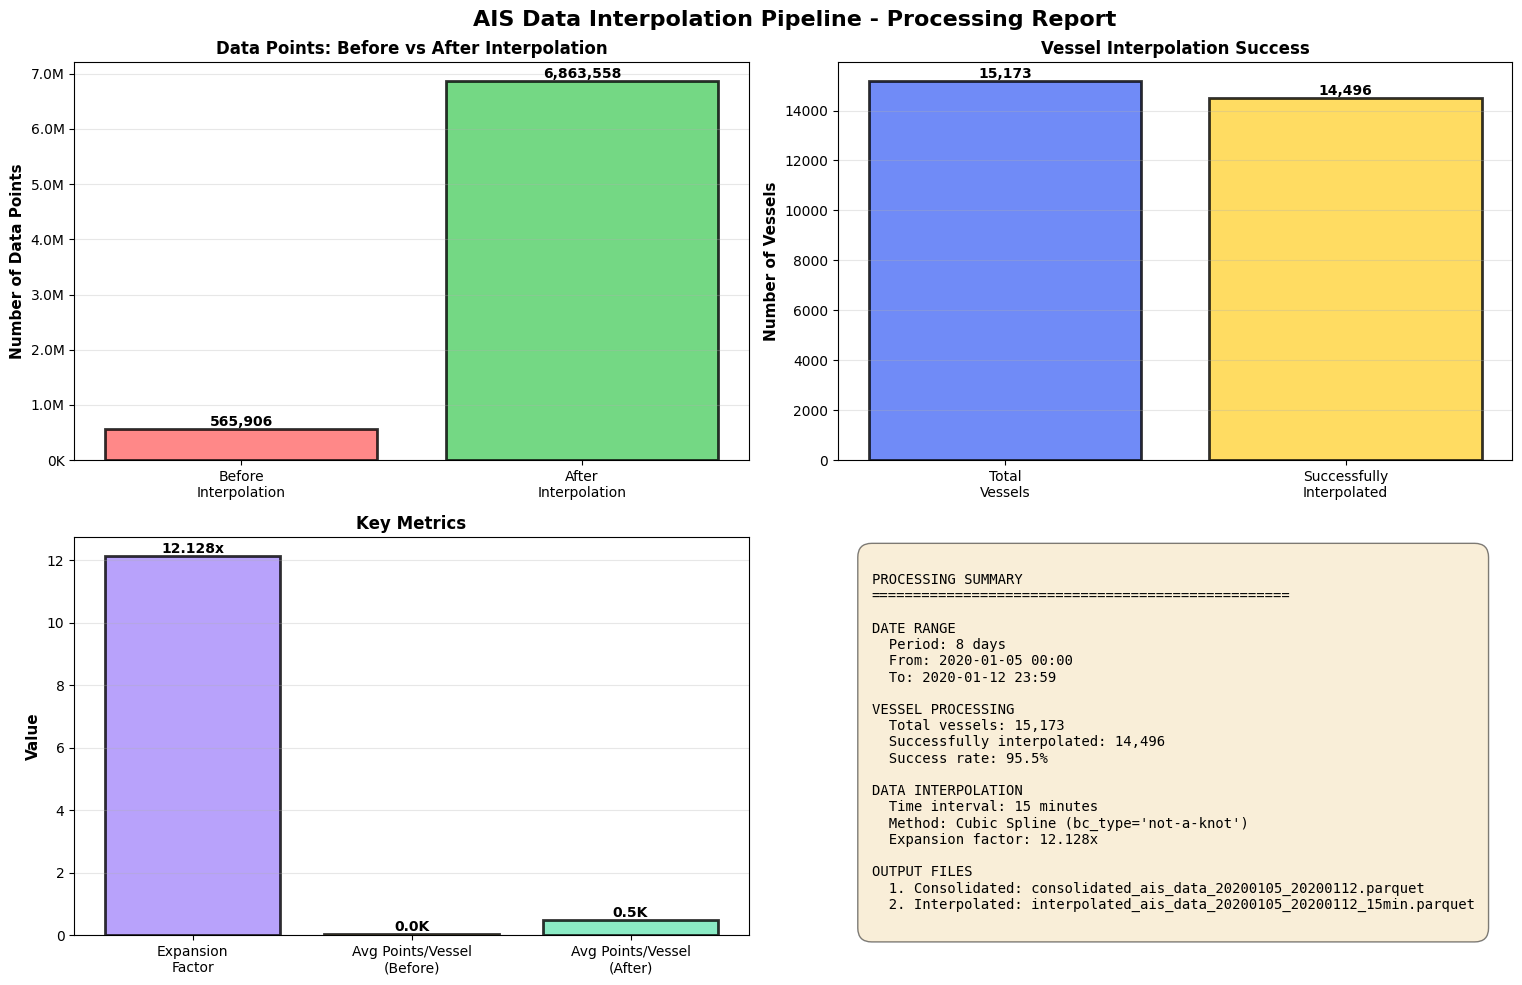


✅ Visualization complete!


In [9]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "AIS Data Interpolation Pipeline - Processing Report",
    fontsize=16,
    fontweight="bold",
)

# 1. Data points before/after
ax = axes[0, 0]
categories = ["Before\nInterpolation", "After\nInterpolation"]
values = [total_points_before, total_points_after]
colors = ["#FF6B6B", "#51CF66"]
ax.bar(categories, values, color=colors, edgecolor="black", linewidth=2, alpha=0.8)
ax.set_ylabel("Number of Data Points", fontweight="bold", fontsize=11)
ax.set_title(
    "Data Points: Before vs After Interpolation", fontweight="bold", fontsize=12
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, p: f"{int(x/1e6):.1f}M" if x >= 1e6 else f"{int(x/1e3):.0f}K"
    )
)
ax.grid(axis="y", alpha=0.3)

# Add value labels
for i, (cat, val) in enumerate(zip(categories, values)):
    ax.text(i, val, f"{int(val):,}", ha="center", va="bottom", fontweight="bold")

# 2. Vessel statistics
ax = axes[0, 1]
vessel_categories = ["Total\nVessels", "Successfully\nInterpolated"]
vessel_values = [total_vessels, successful_vessels]
vessel_colors = ["#4C6EF5", "#FFD43B"]
ax.bar(
    vessel_categories,
    vessel_values,
    color=vessel_colors,
    edgecolor="black",
    linewidth=2,
    alpha=0.8,
)
ax.set_ylabel("Number of Vessels", fontweight="bold", fontsize=11)
ax.set_title("Vessel Interpolation Success", fontweight="bold", fontsize=12)
ax.grid(axis="y", alpha=0.3)

for i, (cat, val) in enumerate(zip(vessel_categories, vessel_values)):
    ax.text(i, val, f"{int(val):,}", ha="center", va="bottom", fontweight="bold")

# 3. Expansion factor and metrics
ax = axes[1, 0]
metrics = [
    "Expansion\nFactor",
    "Avg Points/Vessel\n(Before)",
    "Avg Points/Vessel\n(After)",
]
metric_values = [
    expansion_factor,
    avg_points_per_vessel_before / 1000,
    avg_points_per_vessel_after / 1000,
]
metric_colors = ["#A78BFA", "#FBBF24", "#6EE7B7"]
ax.bar(
    metrics,
    metric_values,
    color=metric_colors,
    edgecolor="black",
    linewidth=2,
    alpha=0.8,
)
ax.set_ylabel("Value", fontweight="bold", fontsize=11)
ax.set_title("Key Metrics", fontweight="bold", fontsize=12)
ax.grid(axis="y", alpha=0.3)

for i, (met, val) in enumerate(zip(metrics, metric_values)):
    if i == 0:
        ax.text(i, val, f"{val:.3f}x", ha="center", va="bottom", fontweight="bold")
    else:
        ax.text(i, val, f"{val:.1f}K", ha="center", va="bottom", fontweight="bold")

# 4. Summary statistics text
ax = axes[1, 1]
ax.axis("off")

summary_text = f"""
PROCESSING SUMMARY
{'='*50}

DATE RANGE
  Period: {date_range} days
  From: {min_date.strftime('%Y-%m-%d %H:%M')}
  To: {max_date.strftime('%Y-%m-%d %H:%M')}

VESSEL PROCESSING
  Total vessels: {total_vessels:,}
  Successfully interpolated: {successful_vessels:,}
  Success rate: {100*successful_vessels/total_vessels:.1f}%

DATA INTERPOLATION
  Time interval: 15 minutes
  Method: Cubic Spline (bc_type='not-a-knot')
  Expansion factor: {expansion_factor:.3f}x

OUTPUT FILES
  1. Consolidated: {consolidated_file.name}
  2. Interpolated: {interpolated_file.name}
"""

ax.text(
    0.05,
    0.95,
    summary_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5, pad=1),
)

plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")